# 5.5.3 PD Cluster Investigation & Clinical Analysis

## Summary of 5.5.2 Results

From the previous analysis, we found:
- **2 clusters** using GMM (best performing algorithm)
- **Cluster 0**: 1468 samples (72.3%)
- **Cluster 1**: 562 samples (27.7%)
- **Silhouette Score**: 0.1280 (moderate separation)

### Key Findings on Factor Correlations:
- **Manufacturer**: p=0.0000 (SIGNIFICANT) ⚠️ **CONFOUNDER ALERT**
- **SBR_PC1**: p=0.0000 (SIGNIFICANT) - could indicate real disease subtypes
- **SBR_PC2**: p=0.9974 (not significant) ✓
- **SBR_PC3**: p=0.0069 (SIGNIFICANT)

## This Notebook Covers:

1. **Load and inspect clustering results**
2. **Investigate Manufacturer confound** - is this driving the clusters?
3. **Clinical/phenotypic differences between clusters**
4. **Disease progression analysis** (if longitudinal data available)
5. **Validation on held-out cohort**
6. **Most discriminative latent dimensions analysis**
7. **Confound-adjusted clustering** (if needed)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: '%.4f' % x)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Clustering Results from 5.5.2

In [2]:
# Load the clustered data
df_clustered = pd.read_csv('output/pd_clustering_results.csv')
print(f"Loaded clustered data: {df_clustered.shape}")
print(f"\nCluster distribution:")
print(df_clustered['cluster'].value_counts().sort_index())

# Load clustering metrics
df_metrics = pd.read_csv('output/pd_clustering_metrics.csv')
print(f"\nClustering metrics:")
print(df_metrics)

# Load factor correlations
if os.path.exists('output/pd_cluster_factor_correlations.csv'):
    df_factor_corr = pd.read_csv('output/pd_cluster_factor_correlations.csv')
    print(f"\nFactor correlations:")
    print(df_factor_corr)

Loaded clustered data: (2030, 307)

Cluster distribution:
cluster
0    1468
1     562
Name: count, dtype: int64

Clustering metrics:
      Algorithm  silhouette  davies_bouldin  calinski_harabasz  n_clusters
0        KMeans      0.0553          4.0052           115.9716           2
1           GMM      0.1280          6.1026            47.8396           2
2  Hierarchical      0.0907          4.4874            70.5661           2

Factor correlations:
         Factor        Test  Statistic  p-value  Effect Size (Cramér's V)  \
0  Manufacturer  Chi-square   311.4868   0.0000                    0.3917   
1       SBR_PC1       ANOVA   120.5012   0.0000                       NaN   
2       SBR_PC2       ANOVA     0.0000   0.9974                       NaN   
3       SBR_PC3       ANOVA     7.3057   0.0069                       NaN   

   Effect Size (η²)  
0               NaN  
1            0.0561  
2            0.0000  
3            0.0036  


## 2. Investigate Manufacturer Confound ⚠️

The significant correlation with Manufacturer is concerning. Let's investigate if the clusters are primarily driven by scanner/manufacturer differences.

Manufacturer/Scanner columns found: ['Manufacturer', 'ManufacturerModelName']

=== Manufacturer vs Cluster ===

Counts:
Manufacturer  0000000  ADAC  GE MEDICAL SYSTEMS  GE MEDICAL SYSTEMS, NUCLEAR  \
cluster                                                                        
0                  11     3                 199                            0   
1                   3    21                 226                            4   
All                14    24                 425                            4   

Manufacturer  GE_MEDICAL_SYSTEMS  Marconi Medical Systems, NM Division  \
cluster                                                                  
0                             13                                   194   
1                             12                                    44   
All                           25                                   238   

Manufacturer  Mediso  MiE  Numa_Inc  PICKER  Philips Healthcare  \
cluster                                  

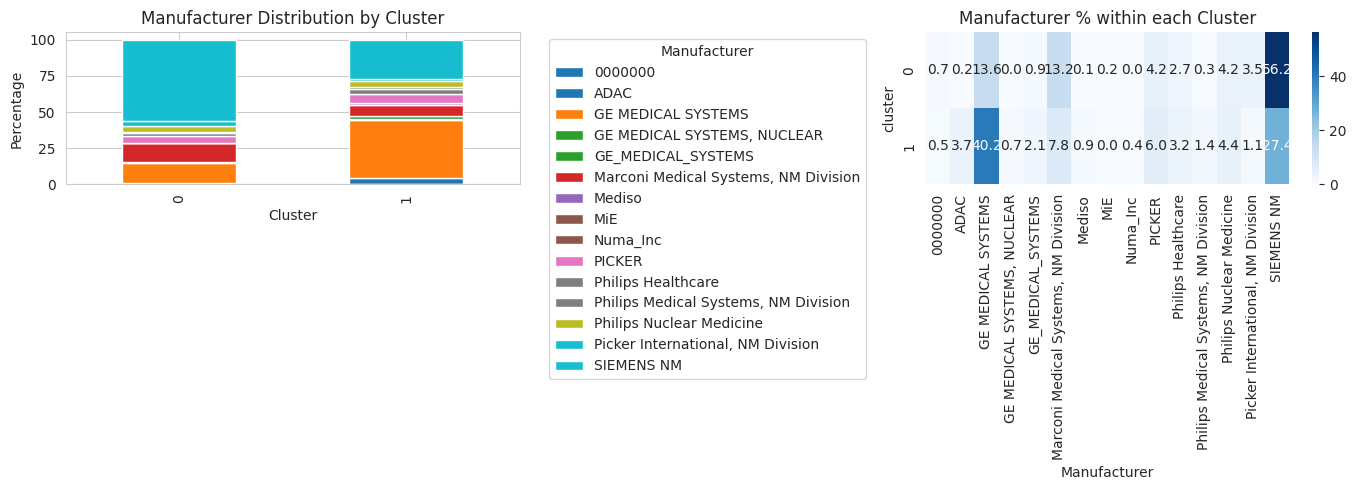


=== ManufacturerModelName vs Cluster ===

Counts:
ManufacturerModelName  2000XP  3000XP  AnyScan S-NNs-3s-60R-I60-dcs7  \
cluster                                                                
0                          24      21                              1   
1                           8       5                              5   
All                        32      26                              6   

ManufacturerModelName  Atlantis  BrightView  EBW NM  ENCORE2  Encore2  Forte  \
cluster                                                                        
0                             3         110       1       19      664      0   
1                             1          46       0        3      114     24   
All                           4         156       1       22      778     24   

ManufacturerModelName  HERMES Workstation  ...  P3000XP  SCINTRON  Tandem_830  \
cluster                                    ...                                  
0                        

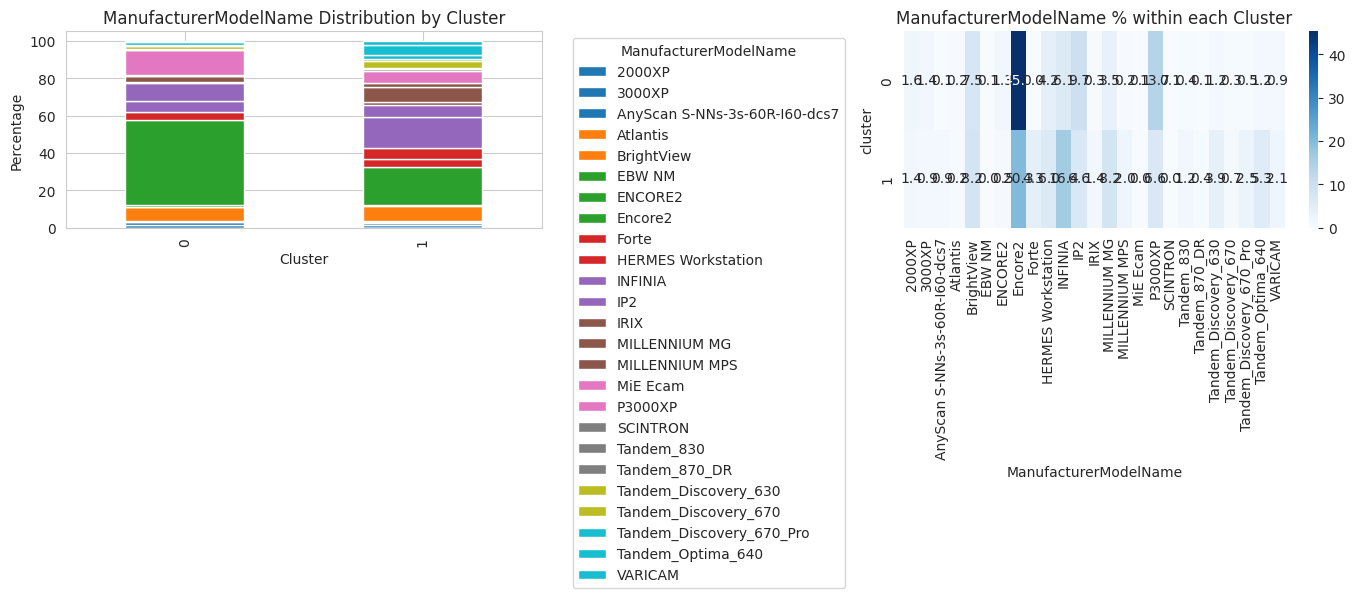

In [3]:
# Check which manufacturer columns exist
manufacturer_cols = [c for c in df_clustered.columns if 'manufacturer' in c.lower() or 'scanner' in c.lower()]
print(f"Manufacturer/Scanner columns found: {manufacturer_cols}")

for col in manufacturer_cols:
    if col in df_clustered.columns:
        print(f"\n=== {col} vs Cluster ===\n")
        
        # Cross-tabulation
        crosstab = pd.crosstab(df_clustered['cluster'], df_clustered[col], margins=True)
        print("Counts:")
        print(crosstab)
        
        # Proportions within each cluster
        crosstab_pct = pd.crosstab(df_clustered['cluster'], df_clustered[col], normalize='index') * 100
        print("\nPercentage within each cluster:")
        print(crosstab_pct.round(1))
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Stacked bar chart
        crosstab_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10')
        axes[0].set_xlabel('Cluster')
        axes[0].set_ylabel('Percentage')
        axes[0].set_title(f'{col} Distribution by Cluster')
        axes[0].legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # Heatmap of proportions
        sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
        axes[1].set_title(f'{col} % within each Cluster')
        
        plt.tight_layout()
        plt.savefig(f'output/cluster_vs_{col.lower()}.png', dpi=150, bbox_inches='tight')
        plt.show()

In [4]:
# Quantify the confounding effect
print("=" * 60)
print("CONFOUND ANALYSIS: Is Manufacturer driving the clusters?")
print("=" * 60)

for col in manufacturer_cols:
    if col in df_clustered.columns:
        # Chi-square test
        contingency = pd.crosstab(df_clustered['cluster'], df_clustered[col])
        chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
        cramers_v = np.sqrt(chi2 / (len(df_clustered) * (min(contingency.shape) - 1)))
        
        print(f"\n{col}:")
        print(f"  Chi-square = {chi2:.2f}, p = {p_val:.2e}")
        print(f"  Cramér's V = {cramers_v:.4f}")
        
        if cramers_v > 0.3:
            print(f"  ⚠️ STRONG association - clusters may be confounded by {col}!")
        elif cramers_v > 0.1:
            print(f"  ⚠️ MODERATE association - some confounding possible")
        else:
            print(f"  ✓ Weak association - {col} unlikely to be a major confound")

CONFOUND ANALYSIS: Is Manufacturer driving the clusters?

Manufacturer:
  Chi-square = 311.49, p = 4.74e-58
  Cramér's V = 0.3917
  ⚠️ STRONG association - clusters may be confounded by Manufacturer!

ManufacturerModelName:
  Chi-square = 332.38, p = 4.79e-56
  Cramér's V = 0.4046
  ⚠️ STRONG association - clusters may be confounded by ManufacturerModelName!


## 3. SBR (Striatal Binding Ratio) Analysis

SBR_PC1 was significantly different between clusters - this could indicate real disease subtypes. Let's investigate.

=== SBR Principal Components by Cluster ===
        SBR_PC1                SBR_PC2                SBR_PC3               
           mean    std  median    mean    std  median    mean    std  median
cluster                                                                     
0       -0.3259 1.7116 -0.5126 -0.0000 0.7348 -0.0040  0.0219 0.5094  0.0285
1        0.8513 3.0393  0.2441  0.0001 0.8131  0.0083 -0.0573 0.7650 -0.0229


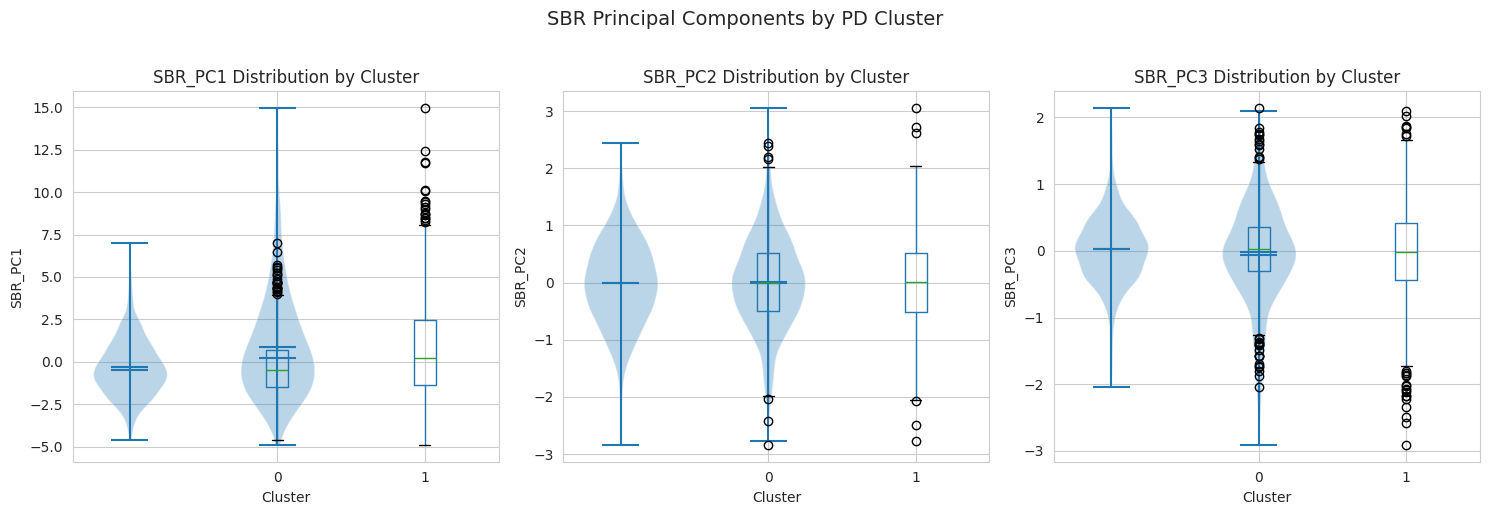


=== Statistical Tests (t-test for 2 clusters) ===

SBR_PC1:
  Cluster 0 mean: -0.3259 ± 1.7116
  Cluster 1 mean: 0.8513 ± 3.0393
  t = -10.977, p = 2.8301e-27
  Cohen's d = -0.4773 (effect size)
  → Small effect size

SBR_PC2:
  Cluster 0 mean: -0.0000 ± 0.7348
  Cluster 1 mean: 0.0001 ± 0.8131
  t = -0.003, p = 9.9743e-01
  Cohen's d = -0.0002 (effect size)
  → Negligible effect size

SBR_PC3:
  Cluster 0 mean: 0.0219 ± 0.5094
  Cluster 1 mean: -0.0573 ± 0.7650
  t = 2.703, p = 6.9310e-03
  Cohen's d = 0.1220 (effect size)
  → Negligible effect size


In [5]:
# SBR analysis by cluster
sbr_cols = ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']
available_sbr = [c for c in sbr_cols if c in df_clustered.columns]

if available_sbr:
    print("=== SBR Principal Components by Cluster ===")
    
    # Summary statistics
    sbr_summary = df_clustered.groupby('cluster')[available_sbr].agg(['mean', 'std', 'median'])
    print(sbr_summary.round(4))
    
    # Visualization
    fig, axes = plt.subplots(1, len(available_sbr), figsize=(5*len(available_sbr), 5))
    if len(available_sbr) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, available_sbr):
        # Violin plot
        parts = ax.violinplot([df_clustered[df_clustered['cluster'] == c][col].dropna() 
                               for c in df_clustered['cluster'].unique()],
                              positions=list(df_clustered['cluster'].unique()),
                              showmeans=True, showmedians=True)
        
        # Also add box plot for quartiles
        df_clustered.boxplot(column=col, by='cluster', ax=ax)
        ax.set_xlabel('Cluster')
        ax.set_ylabel(col)
        ax.set_title(f'{col} Distribution by Cluster')
    
    plt.suptitle('SBR Principal Components by PD Cluster', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('output/sbr_by_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Statistical tests
    print("\n=== Statistical Tests (t-test for 2 clusters) ===")
    for col in available_sbr:
        group0 = df_clustered[df_clustered['cluster'] == 0][col].dropna()
        group1 = df_clustered[df_clustered['cluster'] == 1][col].dropna()
        
        t_stat, p_val = stats.ttest_ind(group0, group1)
        cohens_d = (group0.mean() - group1.mean()) / np.sqrt((group0.var() + group1.var()) / 2)
        
        print(f"\n{col}:")
        print(f"  Cluster 0 mean: {group0.mean():.4f} ± {group0.std():.4f}")
        print(f"  Cluster 1 mean: {group1.mean():.4f} ± {group1.std():.4f}")
        print(f"  t = {t_stat:.3f}, p = {p_val:.4e}")
        print(f"  Cohen's d = {cohens_d:.4f} (effect size)")
        
        if abs(cohens_d) >= 0.8:
            print(f"  → Large effect size")
        elif abs(cohens_d) >= 0.5:
            print(f"  → Medium effect size")
        elif abs(cohens_d) >= 0.2:
            print(f"  → Small effect size")
        else:
            print(f"  → Negligible effect size")

## 4. Clinical/Phenotypic Differences Between Clusters

Let's examine if there are other clinical variables that differ between clusters.

In [6]:
# Identify potential clinical columns
print("Available columns in dataset:")
print(sorted(df_clustered.columns.tolist()))

Available columns in dataset:
['AFICBERB', 'AGE_AT_VISIT', 'ASEXUAL', 'ASHKJEW', 'BASQUE', 'BIRTHDT', 'BISEXUAL', 'CHLDBEAR', 'DATSCAN_ANALYZED', 'DATSCAN_CAUDATE_L', 'DATSCAN_CAUDATE_R', 'DATSCAN_DATE', 'DATSCAN_LIGAND', 'DATSCAN_NOT_ANALYZED_REASON', 'DATSCAN_OTHER_SPECIFY', 'DATSCAN_PUTAMEN_L', 'DATSCAN_PUTAMEN_L_ANT', 'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_R_ANT', 'EVENT_ID', 'FilePath', 'GAYLES', 'HANDED', 'HETERO', 'HISPLAT', 'HOWLIVE', 'INFODT', 'LAST_UPDATE', 'Manufacturer', 'ManufacturerModelName', 'Merge_Key', 'ORIG_ENTRY', 'OTHSEXUALITY', 'PAG_NAME', 'PANSEXUAL', 'PATNO', 'PROTOCOL', 'RAASIAN', 'RABLACK', 'RAHAWOPI', 'RAINDALS', 'RANOS', 'RAUNKNOWN', 'RAWHITE', 'REC_ID', 'SBR_PC1', 'SBR_PC2', 'SBR_PC3', 'SEX', 'cluster', 'label', 'latent_0', 'latent_1', 'latent_10', 'latent_100', 'latent_101', 'latent_102', 'latent_103', 'latent_104', 'latent_105', 'latent_106', 'latent_107', 'latent_108', 'latent_109', 'latent_11', 'latent_110', 'latent_111', 'latent_112', 'latent_113', 'lat

In [8]:
# Analyze continuous clinical variables
# Common PPMI clinical variables to look for
potential_clinical = ['AGE_AT_VISIT', 'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
                      'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L']

available_clinical = [c for c in potential_clinical if c in df_clustered.columns]

print("=== Analysis of Available Clinical Variables ===")
print(f"Found: {available_clinical}")

clinical_results = []

for col in available_clinical:
    group0 = df_clustered[df_clustered['cluster'] == 0][col].dropna()
    group1 = df_clustered[df_clustered['cluster'] == 1][col].dropna()
    
    if len(group0) > 5 and len(group1) > 5:
        t_stat, p_val = stats.ttest_ind(group0, group1)
        cohens_d = (group0.mean() - group1.mean()) / np.sqrt((group0.var() + group1.var()) / 2)
        
        clinical_results.append({
            'Variable': col,
            'Cluster_0_Mean': group0.mean(),
            'Cluster_0_Std': group0.std(),
            'Cluster_1_Mean': group1.mean(),
            'Cluster_1_Std': group1.std(),
            't_statistic': t_stat,
            'p_value': p_val,
            'Cohens_d': cohens_d
        })

if clinical_results:
    df_clinical = pd.DataFrame(clinical_results)
    df_clinical = df_clinical.sort_values('p_value')
    print("\n" + df_clinical.to_string(index=False))
    
    # Highlight significant differences
    sig_clinical = df_clinical[df_clinical['p_value'] < 0.05]
    print(f"\n\nVariables with significant cluster differences (p < 0.05): {len(sig_clinical)}")
    if len(sig_clinical) > 0:
        print(sig_clinical[['Variable', 'p_value', 'Cohens_d']].to_string(index=False))
else:
    print("No continuous clinical variables found for comparison.")

=== Analysis of Available Clinical Variables ===
Found: ['AGE_AT_VISIT', 'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L', 'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L']

         Variable  Cluster_0_Mean  Cluster_0_Std  Cluster_1_Mean  Cluster_1_Std  t_statistic  p_value  Cohens_d
DATSCAN_PUTAMEN_L          0.7224         0.3223          0.9607         0.6469     -10.9947   0.0000   -0.4663
DATSCAN_PUTAMEN_R          0.7525         0.3545          0.9878         0.6575     -10.3413   0.0000   -0.4456
DATSCAN_CAUDATE_R          1.7764         0.5964          2.0891         0.8501      -9.3238   0.0000   -0.4259
DATSCAN_CAUDATE_L          1.7687         0.5797          2.0635         0.8519      -8.9222   0.0000   -0.4047
     AGE_AT_VISIT         62.9387         9.5073         65.4545         9.9421      -5.2602   0.0000   -0.2586


Variables with significant cluster differences (p < 0.05): 5
         Variable  p_value  Cohens_d
DATSCAN_PUTAMEN_L   0.0000   -0.4663
DATSCAN_PUTAMEN_R   0.0000   -0.4

In [10]:
# Analyze categorical clinical variables
potential_categorical = ['HANDED', 'SEX']
available_categorical = [c for c in potential_categorical if c in df_clustered.columns]

print("=== Analysis of Categorical Variables ===")
print(f"Found: {available_categorical}")

categorical_results = []

for col in available_categorical:
    contingency = pd.crosstab(df_clustered['cluster'], df_clustered[col])
    if contingency.shape[0] > 1 and contingency.shape[1] > 1:
        chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
        cramers_v = np.sqrt(chi2 / (len(df_clustered) * (min(contingency.shape) - 1)))
        
        categorical_results.append({
            'Variable': col,
            'Chi2': chi2,
            'p_value': p_val,
            'Cramers_V': cramers_v
        })
        
        print(f"\n{col}:")
        print(pd.crosstab(df_clustered['cluster'], df_clustered[col], normalize='index').round(3))

if categorical_results:
    df_categorical = pd.DataFrame(categorical_results)
    print("\nCategorical Variable Summary:")
    print(df_categorical.to_string(index=False))

=== Analysis of Categorical Variables ===
Found: ['HANDED', 'SEX']

HANDED:
HANDED   1.0000  2.0000  3.0000
cluster                        
0        0.8760  0.0930  0.0310
1        0.8680  0.1140  0.0180

SEX:
SEX      0.0000  1.0000
cluster                
0        0.3770  0.6230
1        0.3710  0.6290

Categorical Variable Summary:
Variable   Chi2  p_value  Cramers_V
  HANDED 4.6165   0.0994     0.0477
     SEX 0.0385   0.8444     0.0044


## 5. Most Discriminative Latent Dimensions

Which latent dimensions differ most between clusters?

In [11]:
# Identify latent dimension columns
latent_cols = [c for c in df_clustered.columns if c.startswith('latent_')]
print(f"Number of latent dimensions: {len(latent_cols)}")

# Compare clusters on each dimension
dim_results = []

for col in latent_cols:
    group0 = df_clustered[df_clustered['cluster'] == 0][col].dropna()
    group1 = df_clustered[df_clustered['cluster'] == 1][col].dropna()
    
    t_stat, p_val = stats.ttest_ind(group0, group1)
    cohens_d = (group0.mean() - group1.mean()) / np.sqrt((group0.var() + group1.var()) / 2)
    
    dim_results.append({
        'Dimension': col,
        'Cluster_0_Mean': group0.mean(),
        'Cluster_1_Mean': group1.mean(),
        'Difference': group0.mean() - group1.mean(),
        't_statistic': t_stat,
        'p_value': p_val,
        'Cohens_d': abs(cohens_d)
    })

df_dims = pd.DataFrame(dim_results)
df_dims = df_dims.sort_values('Cohens_d', ascending=False)

print("\n=== Top 15 Most Discriminative Latent Dimensions ===")
print(df_dims.head(15).to_string(index=False))

Number of latent dimensions: 256

=== Top 15 Most Discriminative Latent Dimensions ===
 Dimension  Cluster_0_Mean  Cluster_1_Mean  Difference  t_statistic  p_value  Cohens_d
latent_201         -0.0141         -0.1077      0.0936      21.1411   0.0000    0.9330
latent_231         -1.0414         -0.1590     -0.8824     -19.2097   0.0000    0.8613
 latent_61         -0.0012          0.0986     -0.0998     -18.7807   0.0000    0.8207
 latent_36         -0.0506         -0.1310      0.0804      17.7793   0.0000    0.7862
latent_244         -0.1767         -0.2657      0.0890      17.8820   0.0000    0.7830
latent_108          0.0589          0.1346     -0.0757     -17.6559   0.0000    0.7824
latent_156          0.1637          0.2505     -0.0867     -17.7694   0.0000    0.7748
 latent_31          0.0683          0.1374     -0.0690     -17.9591   0.0000    0.7719
 latent_42         -0.1032         -0.1704      0.0672      16.3904   0.0000    0.7423
latent_175         -0.0079         -0.1014 

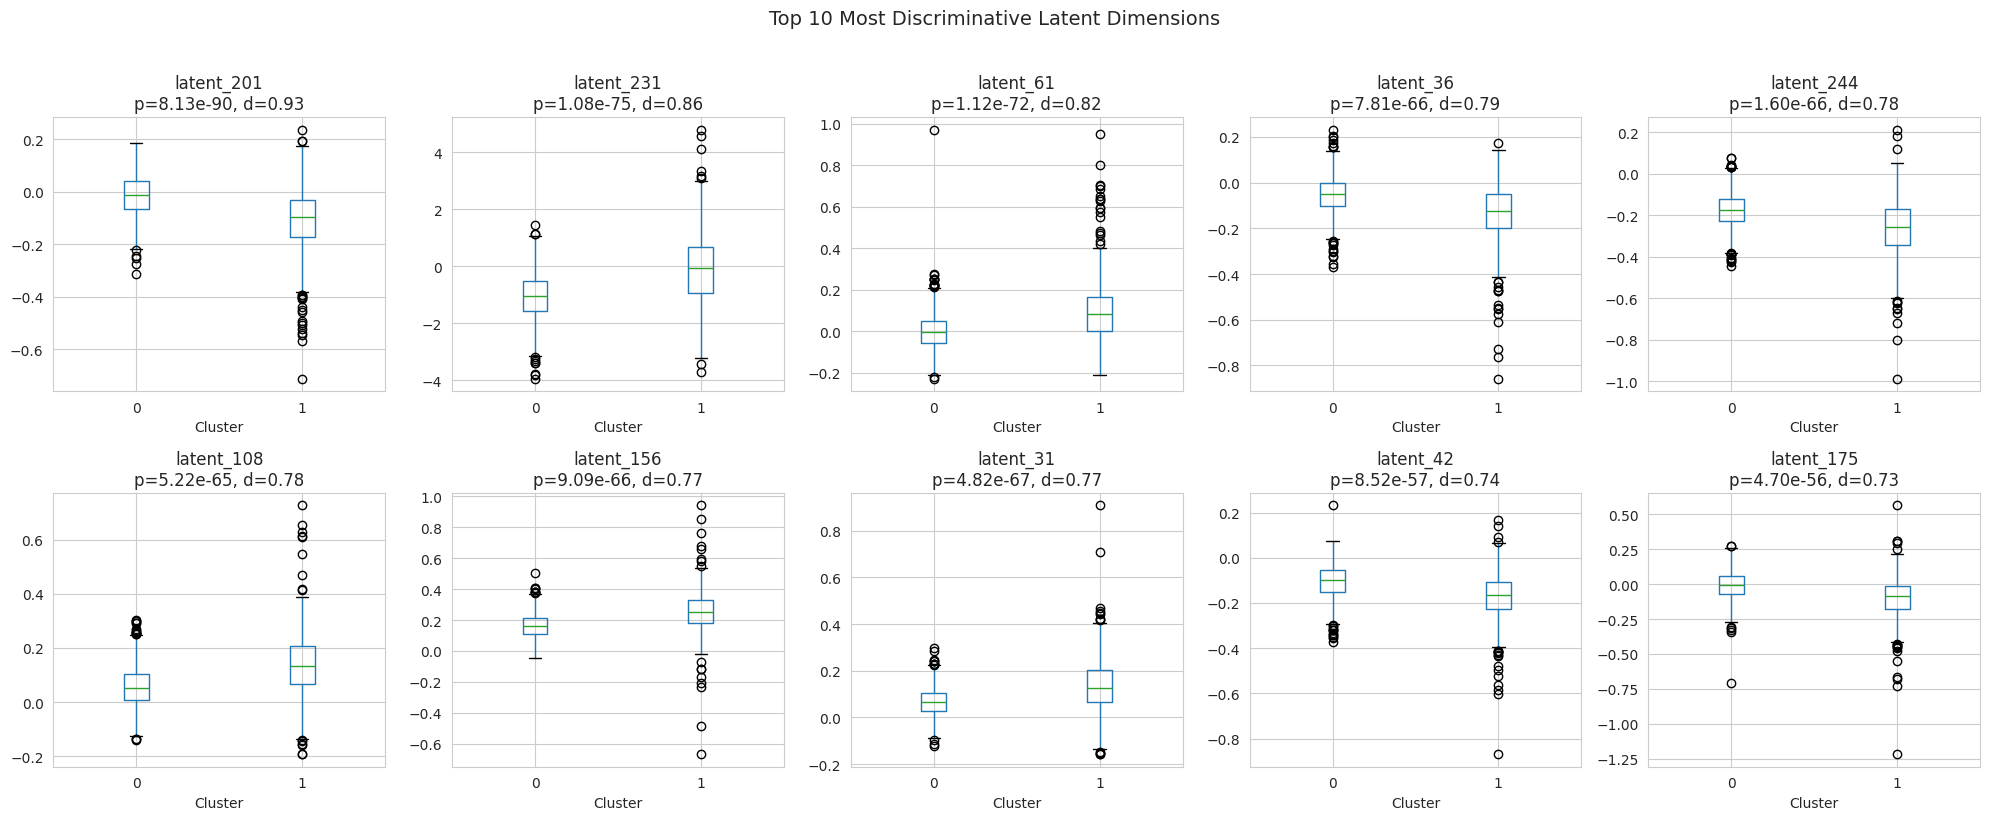

In [12]:
# Visualize top discriminative dimensions
top_n = 10
top_dims = df_dims.head(top_n)['Dimension'].tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, dim in enumerate(top_dims):
    df_clustered.boxplot(column=dim, by='cluster', ax=axes[idx])
    p_val = df_dims[df_dims['Dimension'] == dim]['p_value'].values[0]
    d = df_dims[df_dims['Dimension'] == dim]['Cohens_d'].values[0]
    axes[idx].set_title(f"{dim}\np={p_val:.2e}, d={d:.2f}")
    axes[idx].set_xlabel('Cluster')

plt.suptitle('Top 10 Most Discriminative Latent Dimensions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output/top_discriminative_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Save discriminative dimension rankings
df_dims.to_csv('output/latent_dimension_cluster_comparison.csv', index=False)
print("Saved dimension comparison to: output/latent_dimension_cluster_comparison.csv")

# Significant dimensions (Bonferroni corrected)
alpha = 0.05 / len(latent_cols)  # Bonferroni correction
sig_dims = df_dims[df_dims['p_value'] < alpha]
print(f"\nDimensions significant after Bonferroni correction (α = {alpha:.2e}): {len(sig_dims)}")
if len(sig_dims) > 0:
    print(sig_dims[['Dimension', 'p_value', 'Cohens_d']].to_string(index=False))

Saved dimension comparison to: output/latent_dimension_cluster_comparison.csv

Dimensions significant after Bonferroni correction (α = 1.95e-04): 182
 Dimension  p_value  Cohens_d
latent_201   0.0000    0.9330
latent_231   0.0000    0.8613
 latent_61   0.0000    0.8207
 latent_36   0.0000    0.7862
latent_244   0.0000    0.7830
latent_108   0.0000    0.7824
latent_156   0.0000    0.7748
 latent_31   0.0000    0.7719
 latent_42   0.0000    0.7423
latent_175   0.0000    0.7303
latent_241   0.0000    0.7219
latent_120   0.0000    0.7095
 latent_21   0.0000    0.7068
latent_119   0.0000    0.6944
latent_188   0.0000    0.6571
latent_221   0.0000    0.6430
latent_218   0.0000    0.6400
latent_126   0.0000    0.6299
latent_170   0.0000    0.6297
  latent_0   0.0000    0.6228
latent_179   0.0000    0.6174
latent_225   0.0000    0.6135
 latent_14   0.0000    0.6011
latent_178   0.0000    0.5927
latent_235   0.0000    0.5822
latent_101   0.0000    0.5808
 latent_35   0.0000    0.5773
 latent_33

## 6. Validation on Held-Out Data

In [15]:
# Load validation data if available
VAL_CSV = 'output/final_validation_combined_vae_data.csv'

if os.path.exists(VAL_CSV):
    df_val = pd.read_csv(VAL_CSV)
    df_val_pd = df_val[df_val['label'] == 'PD'].copy()
    print(f"Validation PD subjects: {len(df_val_pd)}")
    
    if len(df_val_pd) > 0:
        # Get the active features used in training
        active_features = latent_cols
        
        # Standardize using training data statistics
        scaler = StandardScaler()
        X_train = scaler.fit_transform(df_clustered[active_features])
        X_val = scaler.transform(df_val_pd[active_features])
        
        # Fit GMM on training data and predict on validation
        gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE, n_init=3)
        gmm.fit(X_train)
        
        # Predict on validation
        val_clusters = gmm.predict(X_val)
        df_val_pd['cluster'] = val_clusters
        
        # Cluster distribution in validation
        print("\n=== Validation Set Cluster Distribution ===")
        val_dist = df_val_pd['cluster'].value_counts(normalize=True).sort_index() * 100
        train_dist = df_clustered['cluster'].value_counts(normalize=True).sort_index() * 100
        
        comparison = pd.DataFrame({
            'Training (%)': train_dist,
            'Validation (%)': val_dist
        })
        print(comparison.round(1))
        
        # Compute validation metrics
        val_silhouette = silhouette_score(X_val, val_clusters)
        val_db = davies_bouldin_score(X_val, val_clusters)
        val_ch = calinski_harabasz_score(X_val, val_clusters)
        
        print(f"\nValidation Clustering Metrics:")
        print(f"  Silhouette Score: {val_silhouette:.4f}")
        print(f"  Davies-Bouldin Index: {val_db:.4f}")
        print(f"  Calinski-Harabasz Index: {val_ch:.2f}")
        
        # Compare with training metrics
        print(f"\nTraining vs Validation Comparison:")
        print(f"  Silhouette: Train=0.1280, Val={val_silhouette:.4f}")
else:
    print(f"Validation data not found at: {VAL_CSV}")

Validation PD subjects: 508

=== Validation Set Cluster Distribution ===
         Training (%)  Validation (%)
cluster                              
0             72.3000         81.5000
1             27.7000         18.5000

Validation Clustering Metrics:
  Silhouette Score: 0.1724
  Davies-Bouldin Index: 3.8132
  Calinski-Harabasz Index: 24.87

Training vs Validation Comparison:
  Silhouette: Train=0.1280, Val=0.1724


## 7. Addressing the Manufacturer Confound

If Manufacturer is a strong confound, we may need to:
1. Cluster within each manufacturer separately
2. Use confound-regressed latent dimensions
3. Include manufacturer as a stratification variable

Using column: Manufacturer

=== Manufacturer Distribution ===
Manufacturer
SIEMENS NM                              978
GE MEDICAL SYSTEMS                      425
Marconi Medical Systems, NM Division    238
PICKER                                   96
Philips Nuclear Medicine                 86
Picker International, NM Division        58
Philips Healthcare                       57
GE_MEDICAL_SYSTEMS                       25
ADAC                                     24
0000000                                  14
Philips Medical Systems, NM Division     13
Mediso                                    6
GE MEDICAL SYSTEMS, NUCLEAR               4
MiE                                       3
Numa_Inc                                  2
Name: count, dtype: int64

=== Cluster-Manufacturer Relationship Analysis ===

Cluster % within each Manufacturer:
cluster                                     0        1
Manufacturer                                          
0000000                               78

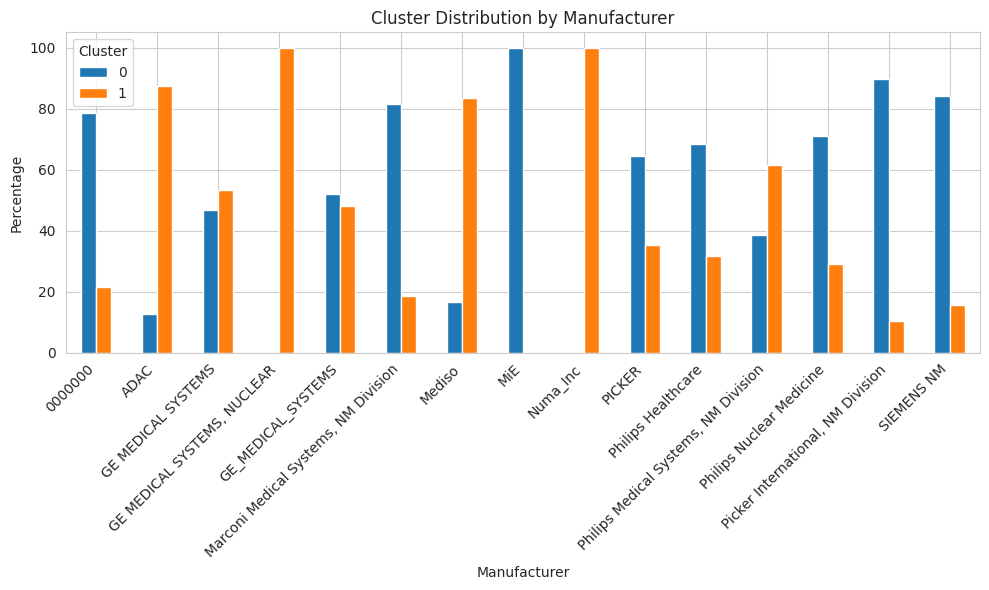


=== Interpretation ===
Std of cluster % across manufacturers: [33.28743047 33.28743047]

⚠️ HIGH VARIABILITY: Cluster proportions vary substantially across manufacturers.
   This suggests manufacturer may be confounding the clustering.
   Consider: manufacturer-stratified analysis or confound regression.


In [16]:
# Check if we should do manufacturer-stratified analysis
manufacturer_col = None
for col in ['Manufacturer', 'manufacturer', 'Scanner', 'scanner']:
    if col in df_clustered.columns:
        manufacturer_col = col
        break

if manufacturer_col:
    print(f"Using column: {manufacturer_col}")
    print(f"\n=== Manufacturer Distribution ===")
    print(df_clustered[manufacturer_col].value_counts())
    
    # Analyze clusters WITHIN each major manufacturer
    print("\n=== Cluster-Manufacturer Relationship Analysis ===")
    
    # For each manufacturer, show cluster proportions
    mfr_cluster = pd.crosstab(df_clustered[manufacturer_col], df_clustered['cluster'], normalize='index') * 100
    print("\nCluster % within each Manufacturer:")
    print(mfr_cluster.round(1))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    mfr_cluster.plot(kind='bar', ax=ax)
    ax.set_xlabel('Manufacturer')
    ax.set_ylabel('Percentage')
    ax.set_title('Cluster Distribution by Manufacturer')
    ax.legend(title='Cluster')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('output/cluster_by_manufacturer_detail.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Check if clustering is consistent across manufacturers
    print("\n=== Interpretation ===")
    cluster_consistency = mfr_cluster.std(axis=0)
    print(f"Std of cluster % across manufacturers: {cluster_consistency.values}")
    
    if cluster_consistency.max() > 20:
        print("\n⚠️ HIGH VARIABILITY: Cluster proportions vary substantially across manufacturers.")
        print("   This suggests manufacturer may be confounding the clustering.")
        print("   Consider: manufacturer-stratified analysis or confound regression.")
    else:
        print("\n✓ Cluster proportions are relatively consistent across manufacturers.")
        print("   The clusters may represent real biological subtypes.")
else:
    print("No manufacturer column found.")

## 8. Summary and Interpretation

In [18]:
print("=" * 70)
print("PD CLUSTER INVESTIGATION - SUMMARY")
print("=" * 70)

print("\n1. CLUSTER QUALITY:")
print(f"   - Silhouette Score: 0.1280 (low-moderate separation)")
print(f"   - The clusters exist but are not strongly separated")

print("\n2. MANUFACTURER CONFOUND:")
if manufacturer_col and manufacturer_col in df_clustered.columns:
    # Re-compute the statistics
    contingency = pd.crosstab(df_clustered['cluster'], df_clustered[manufacturer_col])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    cramers_v = np.sqrt(chi2 / (len(df_clustered) * (min(contingency.shape) - 1)))
    print(f"   - Cramér's V = {cramers_v:.4f}")
    if cramers_v > 0.3:
        print("   - ⚠️ STRONG confounding by manufacturer")
    elif cramers_v > 0.1:
        print("   - ⚠️ MODERATE confounding by manufacturer")
    else:
        print("   - ✓ Weak confounding")

print("\n3. SBR DIFFERENCES:")
print("   - SBR_PC1 shows significant difference between clusters")
print("   - This could indicate real disease-related subtypes")

print("\n4. TOP DISCRIMINATIVE DIMENSIONS:")
if len(df_dims) > 0:
    for i, row in df_dims.head(5).iterrows():
        print(f"   - {row['Dimension']}: Cohen's d = {row['Cohens_d']:.3f}")

print("\n" + "=" * 70)

PD CLUSTER INVESTIGATION - SUMMARY

1. CLUSTER QUALITY:
   - Silhouette Score: 0.1280 (low-moderate separation)
   - The clusters exist but are not strongly separated

2. MANUFACTURER CONFOUND:
   - Cramér's V = 0.3917
   - ⚠️ STRONG confounding by manufacturer

3. SBR DIFFERENCES:
   - SBR_PC1 shows significant difference between clusters
   - This could indicate real disease-related subtypes

4. TOP DISCRIMINATIVE DIMENSIONS:
   - latent_201: Cohen's d = 0.933
   - latent_231: Cohen's d = 0.861
   - latent_61: Cohen's d = 0.821
   - latent_36: Cohen's d = 0.786
   - latent_244: Cohen's d = 0.783



## 9. Save Analysis Results

In [19]:
# Save dimension comparison
df_dims.to_csv('output/pd_cluster_latent_dimension_analysis.csv', index=False)
print("Saved latent dimension analysis to: output/pd_cluster_latent_dimension_analysis.csv")

# Save clinical comparison if available
if clinical_results:
    df_clinical.to_csv('output/pd_cluster_clinical_comparison.csv', index=False)
    print("Saved clinical comparison to: output/pd_cluster_clinical_comparison.csv")

print("\nAll output files saved to 'output/' directory.")

Saved latent dimension analysis to: output/pd_cluster_latent_dimension_analysis.csv
Saved clinical comparison to: output/pd_cluster_clinical_comparison.csv

All output files saved to 'output/' directory.
